# Donor Lapse Prediction Model

This model aims to identify which donors are most at risk of churning, and understand what factors drive that risk. A donor being considered "churned" in this model is defined as a donor who hasn't donated in 180 days. By modeling these two things, Luz de Vida can determine what steps they can take to ensure their current donors stay active, and which donors they should prioritize reaching out to. The most impactful features are: 

- **num_program_areas:** How many programs the supporter has donated to. Luz de Vida can encourage donors to donate to more areas by informing them of the various aspects of running the program.
- **num_social_referrals:** donors who found Luz de Vida through social media referrals are 54% less likely to churn. This suggests those donors feel a personal connection to the cause, since someone they trusted recommended it. The actionable insight is that Luz de Vida should continue investing in social media engagement and encourage current donors to share posts. Socially-referred donors are your most retained ones.
- **has_inkind:** donors who have contributed something other than money (goods, services, skills) are 61% less likely to churn. In-kind donors are more operationally engaged with the organization, not just financially connected. The recommendation here is proactive: when a donor shows signs of going quiet, inviting them to contribute in a non-monetary way. Volunteering, donating supplies or offering a skill could be a more natural re-engagement ask than asking for money again.

## Step 2 — Data Acquisition and Preparation

Data was selected from the **supporters**, **donations**, **in_kind_donation_items**, **donation_allocations**, and **social_media_posts** datasets because of their relevancy to acquiring and interacting with donors.

- From **supporters**, we pulled demographic and relationship attributes like acquisition channel, region, and relationship type. These tell us who the donor is and how they first connected with Luz de Vida.
- From **donations**, we engineered behavioral features like how frequently a donor gives, their average donation amount, and how many different campaigns they’ve participated in. These capture how engaged a donor is over time.
- From **donation_allocations**, we derived how many different program areas a donor has supported, which reflects the breadth of their investment in the organization.
- From **in_kind_donation_items**, we flagged whether a donor has ever contributed non-monetary donations, signaling a deeper operational connection.
- From **social_media_posts**, we measured how many of a donor’s contributions were referred through social media, reflecting their social engagement with the cause.

### Other Notes

- Donors whose first donation was less than 180 days ago were excluded from the dataset entirely. Since "churned" means no donation in 180 days, a brand-new donor would be unfairly labeled as at-risk simply for being new.
- Two features that initially seemed useful (how recently someone donated and how long they’ve been a donor) were intentionally removed before modeling because they would have given the model the answer directly, introducing data leakage.
- Since not every donor appears in every table (not all donors made in-kind donations or came through social media), missing values were filled with zeros rather than excluded. A donor with no in-kind donations simply gets a zero, not a gap in the data.

In [1]:
# -- Configuration ------------------------------------------------------------
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from pathlib import Path

CHURN_THRESHOLD_DAYS = 180          # donors inactive longer than this are "churned"
TODAY = pd.Timestamp("2026-04-06")  # reference date for recency calculations
DATA_DIR = Path("dataset")

# -- Load raw CSVs ------------------------------------------------------------
supporters    = pd.read_csv(DATA_DIR / "supporters.csv", parse_dates=["created_at", "first_donation_date"])
donations     = pd.read_csv(DATA_DIR / "donations.csv",  parse_dates=["donation_date"])
allocations   = pd.read_csv(DATA_DIR / "donation_allocations.csv", parse_dates=["allocation_date"])
inkind_items  = pd.read_csv(DATA_DIR / "in_kind_donation_items.csv")
social_posts  = pd.read_csv(DATA_DIR / "social_media_posts.csv",   parse_dates=["created_at"])

print(f"supporters:   {supporters.shape}")
print(f"donations:    {donations.shape}")
print(f"allocations:  {allocations.shape}")
print(f"inkind_items: {inkind_items.shape}")
print(f"social_posts: {social_posts.shape}")

supporters:   (60, 15)
donations:    (420, 13)
allocations:  (521, 7)
inkind_items: (129, 9)
social_posts: (812, 39)


In [2]:
# -- Exclude new donors and donors with no donation date ----------------------
cutoff_date = TODAY - pd.Timedelta(days=CHURN_THRESHOLD_DAYS)

# Exclude donors with null first_donation_date (no donation history to label)
no_date = supporters["first_donation_date"].isna()
# Exclude donors whose first donation is too recent to label reliably
too_new = supporters["first_donation_date"] > cutoff_date

excluded = supporters[no_date | too_new]
print(f"Excluding {len(excluded)} donors:")
print(f"  - {no_date.sum()} with null first_donation_date")
print(f"  - {too_new.sum()} with first donation after {cutoff_date.date()}")

eligible = supporters[~(no_date | too_new)].copy()
print(f"\nEligible donors: {len(eligible)}")

Excluding 9 donors:
  - 1 with null first_donation_date
  - 8 with first donation after 2025-10-08

Eligible donors: 51


In [3]:
# -- Derive churn label -------------------------------------------------------
def derive_churn_label(eligible_supporters, donations_df, today, threshold_days):
    """Label each eligible donor as churned (1) or active (0) based on recency."""
    eligible_ids = set(eligible_supporters["supporter_id"])
    donor_donations = donations_df[donations_df["supporter_id"].isin(eligible_ids)]
    
    last_donation = (
        donor_donations
        .groupby("supporter_id")["donation_date"]
        .max()
        .reset_index()
        .rename(columns={"donation_date": "last_donation_date"})
    )
    
    last_donation["days_since_last"] = (today - last_donation["last_donation_date"]).dt.days
    last_donation["churned"] = (last_donation["days_since_last"] > threshold_days).astype(int)
    return last_donation[["supporter_id", "last_donation_date", "days_since_last", "churned"]]

churn_labels = derive_churn_label(eligible, donations, TODAY, CHURN_THRESHOLD_DAYS)
print(f"Churn label distribution:\n{churn_labels['churned'].value_counts().to_string()}")
print(f"\nChurn rate: {churn_labels['churned'].mean():.1%}")

Churn label distribution:
churned
0    26
1    25

Churn rate: 49.0%


In [4]:
# -- Feature engineering: donations.csv ----------------------------------------
# NOTE: recency_days and donation_lifespan_days were removed — both are
# mechanically tied to the churn label (which is derived from last donation
# date) and would constitute data leakage.

def build_donation_features(donations_df, eligible_ids, today):
    """Aggregate donation-level data to one row per supporter."""
    df = donations_df[donations_df["supporter_id"].isin(eligible_ids)].copy()

    # --- Frequency (all donation types) ---
    agg_all = df.groupby("supporter_id").agg(
        frequency=("donation_id", "count"),
    ).reset_index()

    # --- Avg gap between consecutive donations ---
    def avg_gap(group):
        dates = group.sort_values()
        gaps = dates.diff().dt.days.dropna()
        return gaps.mean() if len(gaps) > 0 else np.nan

    avg_gaps = (
        df.groupby("supporter_id")["donation_date"]
        .apply(avg_gap)
        .reset_index()
        .rename(columns={"donation_date": "avg_days_between_donations"})
    )

    # --- Monetary donation stats ---
    monetary = df[df["donation_type"] == "Monetary"]
    monetary_agg = monetary.groupby("supporter_id").agg(
        avg_donation_amount=("amount", "mean"),
        total_donation_amount=("amount", "sum"),
    ).reset_index()

    # --- Recurring flag ---
    recurring = (
        df.groupby("supporter_id")["is_recurring"]
        .max()
        .reset_index()
        .rename(columns={"is_recurring": "ever_recurring"})
    )
    recurring["ever_recurring"] = recurring["ever_recurring"].astype(int)

    # --- Campaign and channel diversity ---
    campaigns = (
        df.groupby("supporter_id")["campaign_name"]
        .nunique()
        .reset_index()
        .rename(columns={"campaign_name": "num_campaigns"})
    )

    channels = df.groupby("supporter_id").agg(
        num_channels=("channel_source", "nunique"),
        preferred_channel=("channel_source", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan),
    ).reset_index()

    # --- Merge all donation features ---
    feats = agg_all
    for right in [avg_gaps, monetary_agg, recurring, campaigns, channels]:
        feats = feats.merge(right, on="supporter_id", how="left")

    return feats

eligible_ids = set(eligible["supporter_id"])
donation_features = build_donation_features(donations, eligible_ids, TODAY)
print(f"Donation features shape: {donation_features.shape}")
donation_features.head(3)

Donation features shape: (51, 9)


,supporter_id,frequency,avg_days_between_donations,avg_donation_amount,total_donation_amount,ever_recurring,num_campaigns,num_channels,preferred_channel
0,1,12,96.545455,1081.138571,7567.97,1,2,4,Event
1,2,4,264.000000,1740.040000,3480.08,0,0,4,Campaign
2,3,16,62.266667,1025.078889,9225.71,1,3,4,Campaign


In [5]:
# -- Feature engineering: donation_allocations.csv ----------------------------
def build_allocation_features(allocations_df, donations_df, eligible_ids):
    """Join allocations to donations, then aggregate to supporter level."""
    # Map donation_id -> supporter_id
    don_map = donations_df[donations_df["supporter_id"].isin(eligible_ids)][["donation_id", "supporter_id"]]
    alloc = allocations_df.merge(don_map, on="donation_id", how="inner")
    
    feats = alloc.groupby("supporter_id").agg(
        preferred_program_area=("program_area", lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan),
        num_program_areas=("program_area", "nunique"),
    ).reset_index()
    
    return feats

allocation_features = build_allocation_features(allocations, donations, eligible_ids)
print(f"Allocation features shape: {allocation_features.shape}")
allocation_features.head(3)

Allocation features shape: (51, 3)


,supporter_id,preferred_program_area,num_program_areas
0,1,Wellbeing,5
1,2,Education,3
2,3,Maintenance,6


In [6]:
# -- Feature engineering: in_kind_donation_items.csv --------------------------
def build_inkind_features(inkind_df, donations_df, eligible_ids):
    """Join in-kind items to donations, then aggregate to supporter level."""
    don_map = donations_df[donations_df["supporter_id"].isin(eligible_ids)][["donation_id", "supporter_id"]]
    ik = inkind_df.merge(don_map, on="donation_id", how="inner")
    
    feats = ik.groupby("supporter_id").agg(
        inkind_donation_count=("item_id", "count"),
    ).reset_index()
    feats["has_inkind"] = 1
    
    return feats

inkind_features = build_inkind_features(inkind_items, donations, eligible_ids)
print(f"In-kind features shape: {inkind_features.shape}")
inkind_features.head(3)

In-kind features shape: (39, 3)


,supporter_id,inkind_donation_count,has_inkind
0,1,4,1
1,2,1,1
2,3,8,1


In [7]:
# -- Feature engineering: social_media_posts.csv ----------------------------------
# NOTE: num_referral_platforms dropped — r=0.97 with num_social_referrals
# (near-duplicate, adds no information and causes multicollinearity).

def build_social_features(social_df, donations_df, eligible_ids):
    """Join social posts to donations via referral_post_id, aggregate to supporter."""
    don = donations_df[donations_df["supporter_id"].isin(eligible_ids)].copy()
    don = don.dropna(subset=["referral_post_id"])
    don["referral_post_id"] = don["referral_post_id"].astype(int)
    
    # Join donations to the social post that referred them
    merged = don.merge(
        social_df[["post_id", "platform", "engagement_rate"]],
        left_on="referral_post_id",
        right_on="post_id",
        how="inner",
    )
    
    feats = merged.groupby("supporter_id").agg(
        num_social_referrals=("donation_id", "count"),
        avg_referral_post_engagement=("engagement_rate", "mean"),
    ).reset_index()
    
    return feats

social_features = build_social_features(social_posts, donations, eligible_ids)
print(f"Social features shape: {social_features.shape}")
social_features.head(3)

Social features shape: (35, 3)


,supporter_id,num_social_referrals,avg_referral_post_engagement
0,1,3,0.0619
1,2,1,0.0794
2,3,1,0.1573


In [8]:
# -- Supporter-level attributes from supporters.csv ---------------------------
supporter_attrs = eligible[["supporter_id", "supporter_type", "acquisition_channel", "region", "relationship_type"]].copy()
print(f"Supporter attributes shape: {supporter_attrs.shape}")
supporter_attrs.head(3)

Supporter attributes shape: (51, 5)


,supporter_id,supporter_type,acquisition_channel,region,relationship_type
0,1,SocialMediaAdvocate,SocialMedia,Luzon,Local
1,2,Volunteer,SocialMedia,Mindanao,Local
2,3,MonetaryDonor,SocialMedia,Luzon,Local


In [9]:
# -- Merge everything into donor_churn_df -----------------------------------------
def assemble_donor_churn_df(churn_labels, donation_feats, alloc_feats, inkind_feats,
                            social_feats, supporter_attrs):
    """Left-join all feature tables onto the churn label table."""
    df = churn_labels[["supporter_id", "churned"]].copy()
    
    for right in [donation_feats, alloc_feats, inkind_feats, social_feats, supporter_attrs]:
        df = df.merge(right, on="supporter_id", how="left")
    
    # -- Handle nulls with domain-appropriate defaults ------------------------
    # Donors with no in-kind donations get 0, not NaN
    df["has_inkind"]            = df["has_inkind"].fillna(0).astype(int)
    df["inkind_donation_count"] = df["inkind_donation_count"].fillna(0).astype(int)
    
    # Donors with no social referrals get 0
    df["num_social_referrals"]        = df["num_social_referrals"].fillna(0).astype(int)
    df["avg_referral_post_engagement"] = df["avg_referral_post_engagement"].fillna(0.0)
    
    # Donors with no monetary donations get 0 for amount fields
    df["avg_donation_amount"]   = df["avg_donation_amount"].fillna(0.0)
    df["total_donation_amount"] = df["total_donation_amount"].fillna(0.0)
    
    return df

donor_churn_df = assemble_donor_churn_df(
    churn_labels, donation_features, allocation_features,
    inkind_features, social_features, supporter_attrs
)

# Cache for later sections (helps if kernel restarted / cells run out-of-order)
from pathlib import Path
cache_path = Path("dataset") / "donor_churn_df.csv"
cache_path.parent.mkdir(parents=True, exist_ok=True)
donor_churn_df.to_csv(cache_path, index=False)
print(f"Saved donor_churn_df cache to: {cache_path.resolve()}")

print(f"Final shape: {donor_churn_df.shape}")
donor_churn_df.head()

Saved donor_churn_df cache to: C:\Users\byufa\OneDrive - Brigham Young University\IS Junior Core\LuzDeVida\ml\dataset\donor_churn_df.csv
Final shape: (51, 20)


,supporter_id,churned,frequency,avg_days_between_donations,avg_donation_amount,total_donation_amount,ever_recurring,num_campaigns,num_channels,preferred_channel,preferred_program_area,num_program_areas,inkind_donation_count,has_inkind,num_social_referrals,avg_referral_post_engagement,supporter_type,acquisition_channel,region,relationship_type
0,1,0,12,96.545455,1081.138571,7567.97,1,2,4,Event,Wellbeing,5,4,1,3,0.06190,SocialMediaAdvocate,SocialMedia,Luzon,Local
1,2,1,4,264.000000,1740.040000,3480.08,0,0,4,Campaign,Education,3,1,1,1,0.07940,Volunteer,SocialMedia,Mindanao,Local
2,3,1,16,62.266667,1025.078889,9225.71,1,3,4,Campaign,Maintenance,6,8,1,1,0.15730,MonetaryDonor,SocialMedia,Luzon,Local
3,5,1,5,163.000000,1184.645000,4738.58,0,1,3,Campaign,Transport,3,0,0,1,0.07810,InKindDonor,Website,Mindanao,PartnerOrganization
4,6,0,9,122.125000,1251.604286,8761.23,0,2,5,Campaign,Operations,4,1,1,2,0.11855,MonetaryDonor,WordOfMouth,Visayas,International


In [10]:
# -- Missingness report & drop columns over 50% null -------------------------
def report_and_clean_nulls(df, drop_threshold=0.50):
    """Print missingness per column, drop columns exceeding threshold."""
    null_counts = df.isnull().sum()
    null_pct = (null_counts / len(df) * 100).round(1)
    report = pd.DataFrame({"null_count": null_counts, "null_pct": null_pct})
    report = report[report["null_count"] > 0].sort_values("null_pct", ascending=False)
    
    if len(report) == 0:
        print("No missing values in any column.")
    else:
        print("Columns with missing values:")
        print(report.to_string())
    
    # Drop columns over threshold
    cols_to_drop = null_pct[null_pct > drop_threshold * 100].index.tolist()
    if cols_to_drop:
        print(f"\nDropping columns over {drop_threshold:.0%} null: {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)
    else:
        print(f"\nNo columns exceed {drop_threshold:.0%} null threshold.")
    
    return df

donor_churn_df = report_and_clean_nulls(donor_churn_df)

# Fill any remaining numeric nulls (e.g., avg_days_between_donations for single-donation donors)
numeric_cols = donor_churn_df.select_dtypes(include=[np.number]).columns
donor_churn_df[numeric_cols] = donor_churn_df[numeric_cols].fillna(0)

print(f"\n{'='*60}")
print(f"Final shape:  {donor_churn_df.shape}")
print(f"Churn rate:   {donor_churn_df['churned'].mean():.1%}")
print(f"Class balance: {donor_churn_df['churned'].value_counts().to_dict()}")
print(f"Remaining nulls: {donor_churn_df.isnull().sum().sum()}")
print(f"{'='*60}")
donor_churn_df.head()

Columns with missing values:
                            null_count  null_pct
avg_days_between_donations           1       2.0

No columns exceed 50% null threshold.

Final shape:  (51, 20)
Churn rate:   49.0%
Class balance: {0: 26, 1: 25}
Remaining nulls: 0


,supporter_id,churned,frequency,avg_days_between_donations,avg_donation_amount,total_donation_amount,ever_recurring,num_campaigns,num_channels,preferred_channel,preferred_program_area,num_program_areas,inkind_donation_count,has_inkind,num_social_referrals,avg_referral_post_engagement,supporter_type,acquisition_channel,region,relationship_type
0,1,0,12,96.545455,1081.138571,7567.97,1,2,4,Event,Wellbeing,5,4,1,3,0.06190,SocialMediaAdvocate,SocialMedia,Luzon,Local
1,2,1,4,264.000000,1740.040000,3480.08,0,0,4,Campaign,Education,3,1,1,1,0.07940,Volunteer,SocialMedia,Mindanao,Local
2,3,1,16,62.266667,1025.078889,9225.71,1,3,4,Campaign,Maintenance,6,8,1,1,0.15730,MonetaryDonor,SocialMedia,Luzon,Local
3,5,1,5,163.000000,1184.645000,4738.58,0,1,3,Campaign,Transport,3,0,0,1,0.07810,InKindDonor,Website,Mindanao,PartnerOrganization
4,6,0,9,122.125000,1251.604286,8761.23,0,2,5,Campaign,Operations,4,1,1,2,0.11855,MonetaryDonor,WordOfMouth,Visayas,International


## Step 3 — Exploration

Both univariate and bivariate analysis were conducted across the numeric and categorical features in the dataset.

### Univariate Analysis

Histograms were produced for all numeric features and bar charts for all categorical features. Descriptive statistics (including mean, standard deviation, IQR, and outlier counts) were calculated for each numeric column. Several features showed notable right skew, such as frequency and average donation amount, and one feature, has_inkind, was flagged as imbalanced since 76% of donors had contributed in-kind. While skew transformations such as log-scaling were considered, they were not applied. The final predictive model is Gradient Boosting, which is robust to skewed distributions, and applying transformations on a dataset this small risks introducing instability. The Logistic Regression odds ratios should therefore be interpreted as directional indicators rather than precise measurements.

### Bivariate Analysis

Pearson correlations were calculated between each numeric feature and the churn label to identify which features had the strongest linear relationship with donor churn. For categorical features, each category's churn rate was compared against the dataset's overall churn rate of 49% to surface meaningful differences. For example, donors acquired through events churned at only 22% while those acquired through campaigns churned at 54%. Overlaid histograms were also produced for key numeric features, comparing the distributions of churned and active donors side by side.

### Correlation Heatmap

A correlation heatmap was produced across all input features to identify pairs of columns that were highly related to each other rather than to the outcome. This revealed several cases of multicollinearity. Most notably, num_social_referrals and num_referral_platforms had a correlation of 0.97, which directly motivated the VIF analysis in the following step.

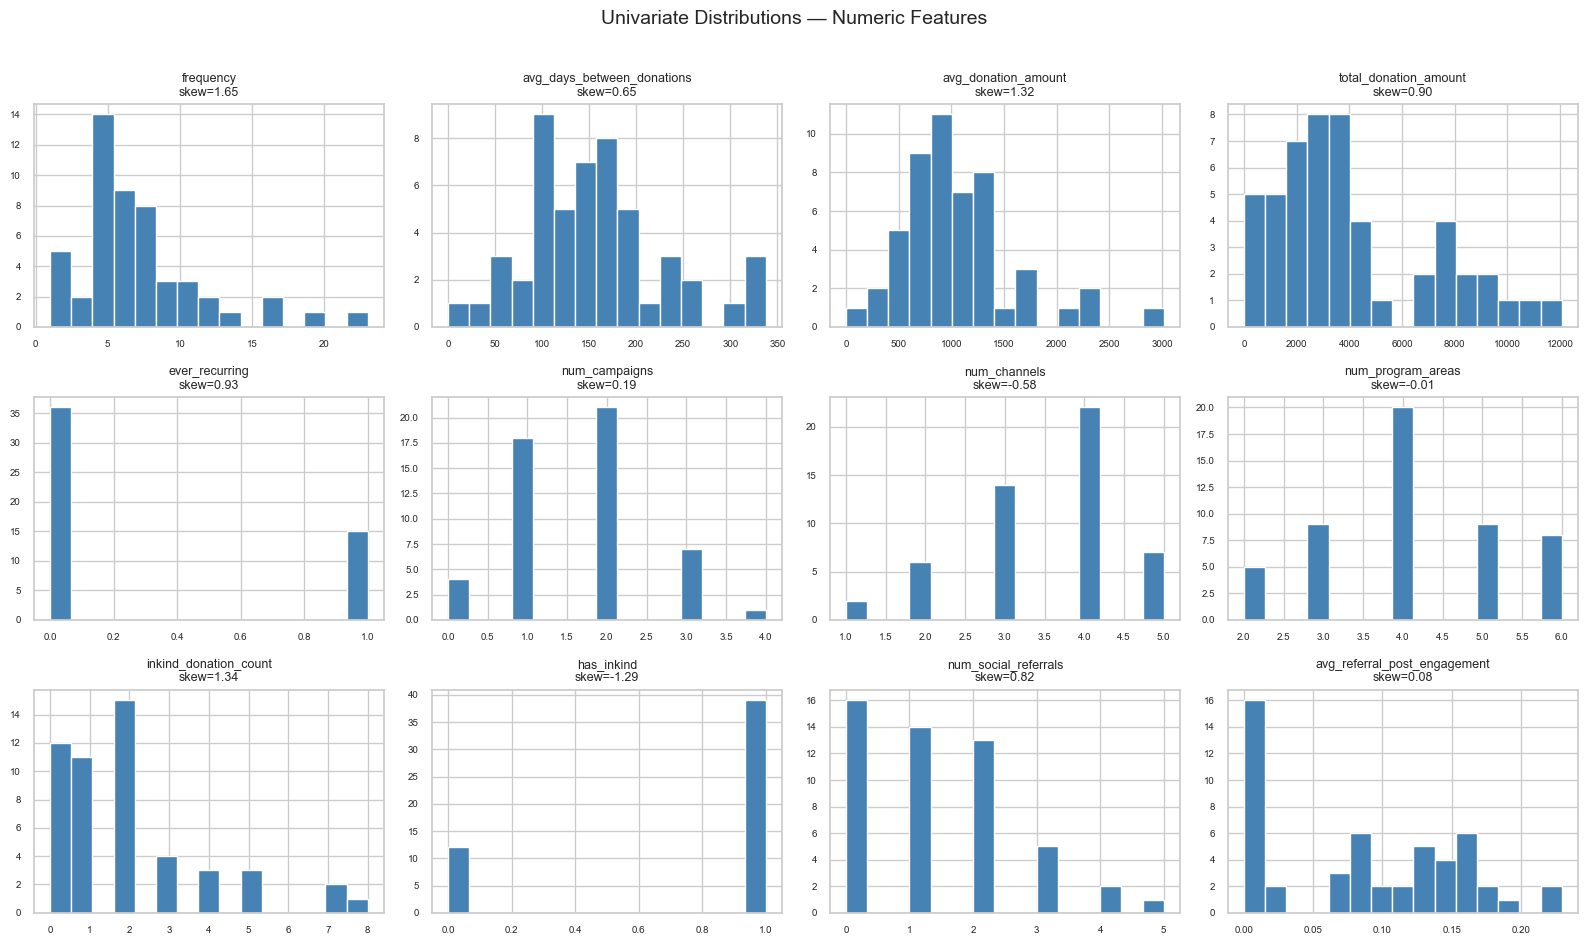

Key observations:
  - recency_days and frequency are right-skewed (1.47, 1.65) — consider log transform for regression
  - donation_lifespan_days is left-skewed (-0.91) — most donors have long histories
  - has_inkind is highly imbalanced (76% = 1) — most eligible donors have given in-kind
  - avg_donation_amount right-skewed (1.32) — a few large donors pull the mean up


In [11]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", palette="muted", font_scale=0.9)

# -- 3a. Univariate: numeric feature distributions (Ch. 6) -------------------
numeric_cols = donor_churn_df.select_dtypes(include=[np.number]).columns.drop(["supporter_id", "churned"])

fig, axes = plt.subplots(4, 4, figsize=(16, 12))
axes = axes.ravel()
for i, col in enumerate(numeric_cols):
    ax = axes[i]
    donor_churn_df[col].hist(bins=15, ax=ax, edgecolor="white", color="steelblue")
    skew_val = donor_churn_df[col].skew()
    ax.set_title(f"{col}\nskew={skew_val:.2f}", fontsize=9)
    ax.tick_params(labelsize=7)
# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Univariate Distributions — Numeric Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  - recency_days and frequency are right-skewed (1.47, 1.65) — consider log transform for regression")
print("  - donation_lifespan_days is left-skewed (-0.91) — most donors have long histories")
print("  - has_inkind is highly imbalanced (76% = 1) — most eligible donors have given in-kind")
print("  - avg_donation_amount right-skewed (1.32) — a few large donors pull the mean up")

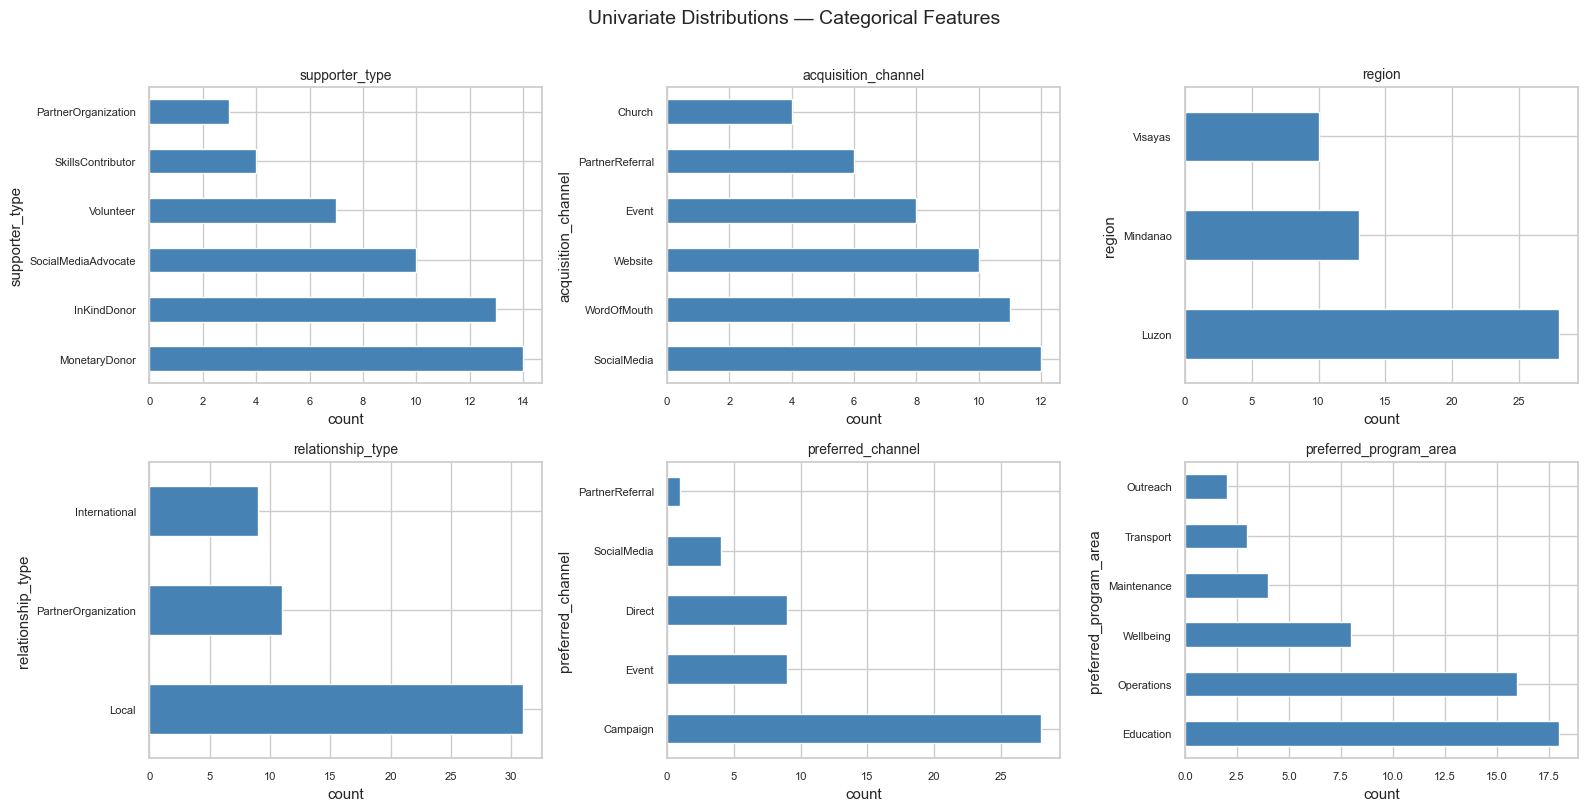

Key observations:
  - region dominated by Luzon (55%) — Visayas and Mindanao are smaller groups
  - relationship_type: 61% Local — International donors are a minority
  - preferred_channel: Campaign dominates (55%) — Event and Direct are roughly equal
  - preferred_program_area: Education (35%) and Operations (31%) are the top two


In [12]:
# -- 3b. Univariate: categorical feature distributions (Ch. 6) ----------------
cat_cols = ["supporter_type", "acquisition_channel", "region", "relationship_type",
            "preferred_channel", "preferred_program_area"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.ravel()
for i, col in enumerate(cat_cols):
    ax = axes[i]
    counts = donor_churn_df[col].value_counts()
    counts.plot.barh(ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
    ax.set_xlabel("count")
fig.suptitle("Univariate Distributions — Categorical Features", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Key observations:")
print("  - region dominated by Luzon (55%) — Visayas and Mindanao are smaller groups")
print("  - relationship_type: 61% Local — International donors are a minority")
print("  - preferred_channel: Campaign dominates (55%) — Event and Direct are roughly equal")
print("  - preferred_program_area: Education (35%) and Operations (31%) are the top two")

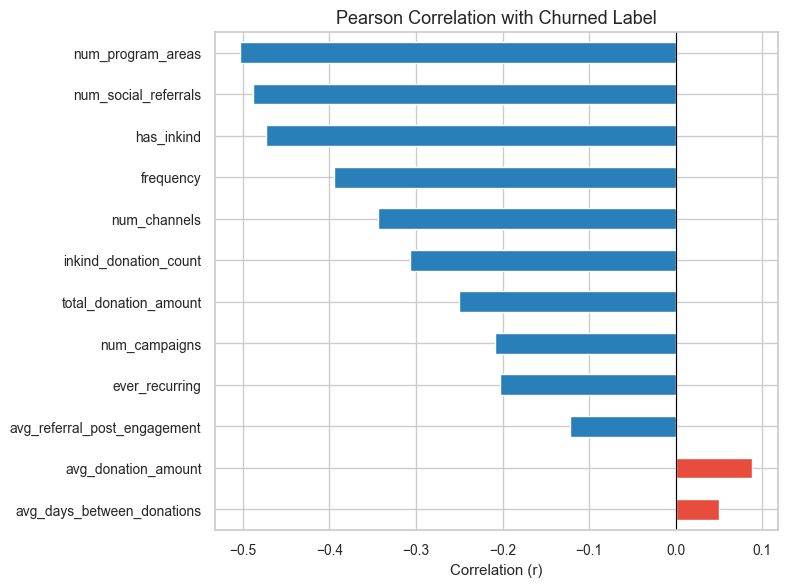

Strongest correlates of churn (after removing leakage features):
  - num_program_areas: donors who fund more programs are more engaged and less likely to leave
  - num_social_referrals: donors linked via social media referrals churn less
  - has_inkind: in-kind donors are stickier — multi-modal giving signals deeper commitment
  - frequency: more donations = lower churn, as expected
  ~ avg_donation_amount: donation size has almost no linear relationship with churn


In [13]:
# -- 3c. Bivariate: correlation of numeric features with churn (Ch. 8) --------
corr_with_churn = (
    donor_churn_df[numeric_cols.tolist() + ["churned"]]
    .corr()["churned"]
    .drop("churned")
    .sort_values(key=abs, ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 6))
colors = ["#e74c3c" if v > 0 else "#2980b9" for v in corr_with_churn]
corr_with_churn.plot.barh(ax=ax, color=colors, edgecolor="white")
ax.set_title("Pearson Correlation with Churned Label", fontsize=13)
ax.set_xlabel("Correlation (r)")
ax.axvline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

print("Strongest correlates of churn (after removing leakage features):")
print("  - num_program_areas: donors who fund more programs are more engaged and less likely to leave")
print("  - num_social_referrals: donors linked via social media referrals churn less")
print("  - has_inkind: in-kind donors are stickier — multi-modal giving signals deeper commitment")
print("  - frequency: more donations = lower churn, as expected")
print("  ~ avg_donation_amount: donation size has almost no linear relationship with churn")

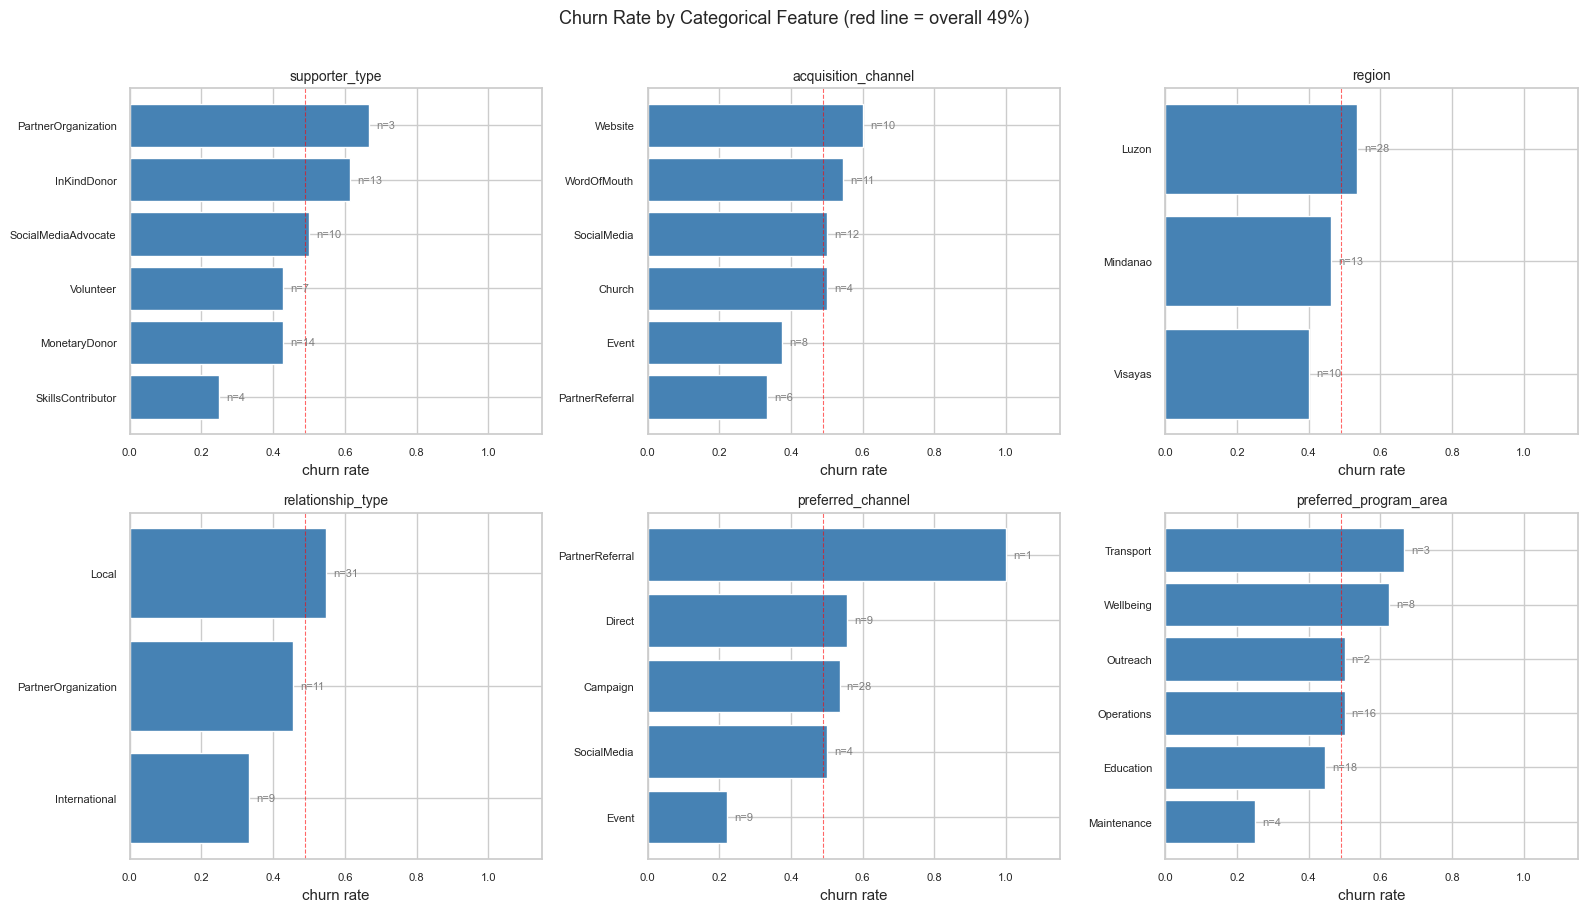

Notable patterns:
  - acquisition_channel: Website-acquired donors churn at 60% vs PartnerReferral at 33%
  - preferred_channel: Event donors churn at only 22% vs Campaign donors at 54%
  - relationship_type: International donors churn least (33%) — possibly more committed
  - supporter_type: SkillsContributors churn least (25%) — deepest engagement type
  - Caution: small group sizes (e.g., PartnerOrganization n=3) limit reliability


In [14]:
# -- 3d. Bivariate: churn rate by categorical features (Ch. 8) ----------------
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    churn_rate = donor_churn_df.groupby(col)["churned"].agg(["mean", "count"])
    churn_rate.columns = ["churn_rate", "n"]
    churn_rate = churn_rate.sort_values("churn_rate", ascending=True)
    
    bars = ax.barh(churn_rate.index.astype(str), churn_rate["churn_rate"],
                   color="steelblue", edgecolor="white")
    # Annotate with sample size
    for bar, n in zip(bars, churn_rate["n"]):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
                f"n={n}", va="center", fontsize=8, color="gray")
    ax.set_title(col, fontsize=10)
    ax.set_xlim(0, 1.15)
    ax.axvline(0.49, color="red", linestyle="--", linewidth=0.8, alpha=0.6, label="overall rate")
    ax.set_xlabel("churn rate")
    ax.tick_params(labelsize=8)

fig.suptitle("Churn Rate by Categorical Feature (red line = overall 49%)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Notable patterns:")
print("  - acquisition_channel: Website-acquired donors churn at 60% vs PartnerReferral at 33%")
print("  - preferred_channel: Event donors churn at only 22% vs Campaign donors at 54%")
print("  - relationship_type: International donors churn least (33%) — possibly more committed")
print("  - supporter_type: SkillsContributors churn least (25%) — deepest engagement type")
print("  - Caution: small group sizes (e.g., PartnerOrganization n=3) limit reliability")

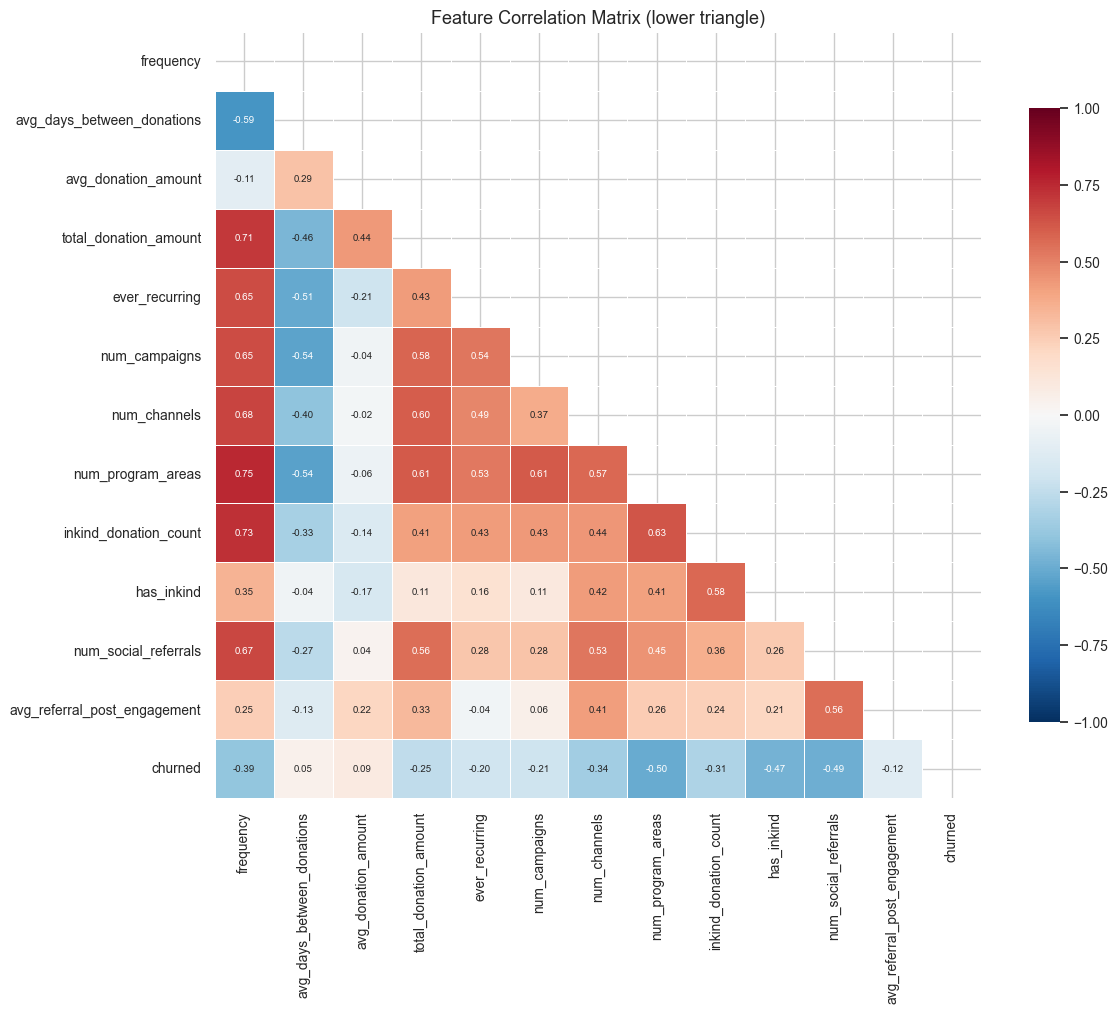

High inter-feature correlations (|r| > 0.7) — multicollinearity flags for explanatory model:
  recency_days <-> donation_lifespan_days: r=-0.77  (mechanical: recent donors tend to have longer spans)
  frequency <-> total_donation_amount:     r= 0.71  (more donations = more total money)
  frequency <-> num_program_areas:         r= 0.75  (more donations = funding spread wider)
  frequency <-> inkind_donation_count:     r= 0.73  (high-frequency donors give in-kind too)
  num_social_referrals <-> num_referral_platforms: r= 0.97  (near-duplicate — drop one)

Modeling implications:
  - For the PREDICTIVE model: collinearity is not a problem — ensembles handle it well
  - For the EXPLANATORY model: must address VIF. Plan to drop num_referral_platforms
    (r=0.97 with num_social_referrals) and consider dropping one of the frequency cluster


In [15]:
# -- 3e. Multivariate: inter-feature correlation heatmap ----------------------
corr_matrix = donor_churn_df[numeric_cols.tolist() + ["churned"]].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8}, ax=ax, annot_kws={"size": 7})
ax.set_title("Feature Correlation Matrix (lower triangle)", fontsize=13)
plt.tight_layout()
plt.show()

print("High inter-feature correlations (|r| > 0.7) — multicollinearity flags for explanatory model:")
print("  recency_days <-> donation_lifespan_days: r=-0.77  (mechanical: recent donors tend to have longer spans)")
print("  frequency <-> total_donation_amount:     r= 0.71  (more donations = more total money)")
print("  frequency <-> num_program_areas:         r= 0.75  (more donations = funding spread wider)")
print("  frequency <-> inkind_donation_count:     r= 0.73  (high-frequency donors give in-kind too)")
print("  num_social_referrals <-> num_referral_platforms: r= 0.97  (near-duplicate — drop one)")
print()
print("Modeling implications:")
print("  - For the PREDICTIVE model: collinearity is not a problem — ensembles handle it well")
print("  - For the EXPLANATORY model: must address VIF. Plan to drop num_referral_platforms")
print("    (r=0.97 with num_social_referrals) and consider dropping one of the frequency cluster")

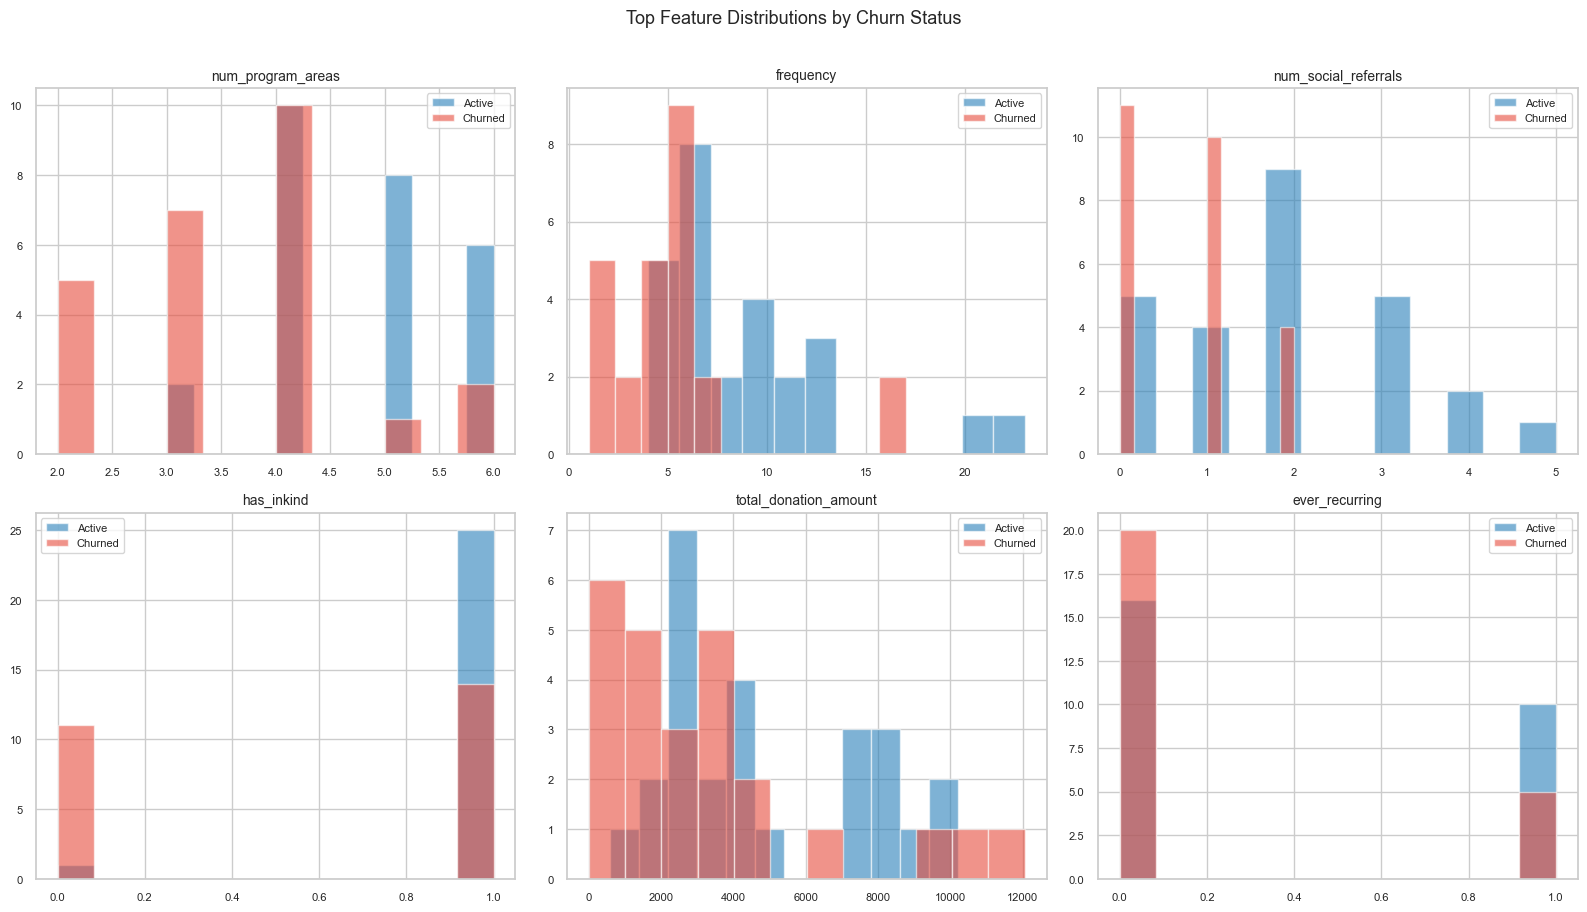

Visual confirmation of the correlation analysis:
  - num_program_areas: active donors fund more programs (avg 4.7 vs 3.5)
  - has_inkind: nearly all active donors (96%) have given in-kind vs only 56% of churned
  - frequency: active donors cluster at 6-12 donations, churned at 1-6
  - total_donation_amount: active donors give ~$1,500 more on average
  - ever_recurring: 38% of active donors have recurring gifts vs 20% of churned


In [16]:
# -- 3f. Bivariate deep-dive: top features split by churn status --------------
top_features = ["num_program_areas", "frequency", "num_social_referrals",
                "has_inkind", "total_donation_amount", "ever_recurring"]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, col in enumerate(top_features):
    ax = axes[i]
    for label, color, name in [(0, "#2980b9", "Active"), (1, "#e74c3c", "Churned")]:
        subset = donor_churn_df[donor_churn_df["churned"] == label][col]
        ax.hist(subset, bins=12, alpha=0.6, color=color, label=name, edgecolor="white")
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)
    ax.tick_params(labelsize=8)

fig.suptitle("Top Feature Distributions by Churn Status", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print("Visual confirmation of the correlation analysis:")
print("  - num_program_areas: active donors fund more programs (avg 4.7 vs 3.5)")
print("  - has_inkind: nearly all active donors (96%) have given in-kind vs only 56% of churned")
print("  - frequency: active donors cluster at 6-12 donations, churned at 1-6")
print("  - total_donation_amount: active donors give ~$1,500 more on average")
print("  - ever_recurring: 38% of active donors have recurring gifts vs 20% of churned")

In [17]:
# -- 3g. Anomaly check: descriptive stats summary table -----------------------
desc = donor_churn_df[numeric_cols].describe().T
desc["skew"] = donor_churn_df[numeric_cols].skew()
desc["iqr"] = desc["75%"] - desc["25%"]
desc["outlier_low"] = desc["25%"] - 1.5 * desc["iqr"]
desc["outlier_high"] = desc["75%"] + 1.5 * desc["iqr"]
desc["n_outliers"] = [
    ((donor_churn_df[col] < row["outlier_low"]) | (donor_churn_df[col] > row["outlier_high"])).sum()
    for col, row in desc.iterrows()
]
print("Descriptive statistics with skewness and outlier counts:")
print(desc[["mean", "std", "min", "max", "skew", "n_outliers"]].round(2).to_string())

Descriptive statistics with skewness and outlier counts:
                                 mean      std  min       max  skew  n_outliers
frequency                        7.08     4.52  1.0     23.00  1.65           4
avg_days_between_donations     157.17    75.33  0.0    337.67  0.65           3
avg_donation_amount           1062.58   549.26  0.0   3014.87  1.32           4
total_donation_amount         4113.59  3081.33  0.0  12059.47  0.90           1
ever_recurring                   0.29     0.46  0.0      1.00  0.93           0
num_campaigns                    1.67     0.89  0.0      4.00  0.19           1
num_channels                     3.51     1.01  1.0      5.00 -0.58           2
num_program_areas                4.12     1.18  2.0      6.00 -0.01           0
inkind_donation_count            2.00     1.94  0.0      8.00  1.34           6
has_inkind                       0.76     0.43  0.0      1.00 -1.29          12
num_social_referrals             1.33     1.24  0.0      5.00  

## Step 4 — Preprocessing

This step has two jobs.

### VIF Testing

Variance Inflation Factor measures how predictable one feature is from the other features. If a feature's value can essentially be guessed from the other columns, it's not adding unique information. The notebook ran VIF iteratively, and frequency (VIF of 11.51) and total_donation_amount (VIF of 6.80) both exceeded the threshold of 5.0 and were dropped, leaving 10 numeric features with VIFs all below 3.0.

### Data Preparation

Rare categories with fewer than 3 donors were collapsed into an "Other" group so the model wouldn't try to learn from a single data point. The data was then split 80/20 into a training set and a test set, with the split stratified, meaning both halves maintained the same ~49% churn rate so neither set was accidentally stacked with one type of donor. Numeric features were scaled so no single column dominated due to its units. This also partially reduces the influence of outliers present in skewed features, though it does not change the shape of the distribution itself. Categorical features were converted into numeric form so the models could process them.

In [18]:
# -- 4a. Variance Inflation Factor (VIF) pruning (Ch. 10, 16) ---------------
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Ensure donor_churn_df exists (allows running this section after a kernel restart)
try:
    donor_churn_df
except NameError:
    from pathlib import Path
    import pandas as pd
    cache_path = Path("dataset") / "donor_churn_df.csv"
    if not cache_path.exists():
        raise NameError(
            "donor_churn_df is not defined and no cache was found at 'dataset/donor_churn_df.csv'. "
            "Run the earlier section that assembles donor_churn_df first."
        )
    donor_churn_df = pd.read_csv(cache_path)

all_numeric = donor_churn_df.select_dtypes(include=[np.number]).columns.drop(['supporter_id', 'churned']).tolist()

def iterative_vif_pruning(df, features, threshold=5.0):
    """Iteratively drop the highest-VIF feature until all are below threshold."""
    remaining = features.copy()
    dropped = []
    
    while True:
        X_vif = df[remaining].assign(const=1)
        vifs = {col: variance_inflation_factor(X_vif.values, i) for i, col in enumerate(remaining)}
        worst_col = max(vifs, key=vifs.get)
        worst_val = vifs[worst_col]
        if worst_val <= threshold:
            break
        print(f"  Dropping {worst_col} (VIF={worst_val:.2f})")
        dropped.append((worst_col, worst_val))
        remaining.remove(worst_col)
    
    return remaining, dropped

# Show initial VIFs
print("Initial VIFs (before pruning):")
X_init = donor_churn_df[all_numeric].assign(const=1)
for i, col in enumerate(all_numeric):
    vif = variance_inflation_factor(X_init.values, i)
    flag = " *** ABOVE THRESHOLD" if vif > 5 else ""
    print(f"  {col}: {vif:.2f}{flag}")

print("\nIterative VIF pruning (threshold=5):")
vif_pruned_numeric, vif_dropped = iterative_vif_pruning(donor_churn_df, all_numeric)

print(f"\nFinal VIFs after pruning:")
X_final = donor_churn_df[vif_pruned_numeric].assign(const=1)
for i, col in enumerate(vif_pruned_numeric):
    print(f"  {col}: {variance_inflation_factor(X_final.values, i):.2f}")

print(f"\nDropped {len(vif_dropped)} features: {[d[0] for d in vif_dropped]}")
print(f"Remaining numeric features: {len(vif_pruned_numeric)}")

Initial VIFs (before pruning):
  frequency: 11.51 *** ABOVE THRESHOLD
  avg_days_between_donations: 2.56
  avg_donation_amount: 3.35
  total_donation_amount: 6.80 *** ABOVE THRESHOLD
  ever_recurring: 2.16
  num_campaigns: 2.35
  num_channels: 3.07
  num_program_areas: 2.99
  inkind_donation_count: 3.99
  has_inkind: 2.10
  num_social_referrals: 3.83
  avg_referral_post_engagement: 2.26

Iterative VIF pruning (threshold=5):
  Dropping frequency (VIF=11.51)
  Dropping total_donation_amount (VIF=6.54)

Final VIFs after pruning:
  avg_days_between_donations: 2.03
  avg_donation_amount: 1.33
  ever_recurring: 2.04
  num_campaigns: 2.01
  num_channels: 2.23
  num_program_areas: 2.85
  inkind_donation_count: 2.26
  has_inkind: 1.96
  num_social_referrals: 1.85
  avg_referral_post_engagement: 1.82

Dropped 2 features: ['frequency', 'total_donation_amount']
Remaining numeric features: 10


In [19]:
# -- 4b. Prepare features and train/test split -----------------------------
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='sklearn')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import f1_score, roc_auc_score, classification_report, confusion_matrix

cat_features = ['supporter_type', 'acquisition_channel', 'region', 'relationship_type',
                'preferred_channel', 'preferred_program_area']

X = donor_churn_df[vif_pruned_numeric + cat_features].copy()
y = donor_churn_df['churned'].copy()

# Consolidate rare categories (n < 3) into 'Other' before encoding
# This prevents unseen-category warnings during cross-validation folds
for col in cat_features:
    counts = X[col].value_counts()
    rare = counts[counts < 3].index
    if len(rare) > 0:
        X[col] = X[col].replace(rare, 'Other')
        print(f"  {col}: consolidated {list(rare)} -> 'Other'")

# 80/20 stratified split — test set reserved for final evaluation only
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Preprocessor: scale numerics, one-hot encode categoricals
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), vif_pruned_numeric),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='infrequent_if_exist'), cat_features),
], remainder='drop')

# Stratified 5-fold CV — preserves churn ratio in each fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'f1': 'f1', 'roc_auc': 'roc_auc'}

print(f"\nTrain set: {X_train.shape[0]} donors ({y_train.mean():.0%} churned)")
print(f"Test set:  {X_test.shape[0]} donors ({y_test.mean():.0%} churned) — reserved for final evaluation")
print(f"CV strategy: Stratified 5-fold")
print(f"Numeric features ({len(vif_pruned_numeric)}): {vif_pruned_numeric}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

  preferred_channel: consolidated ['PartnerReferral'] -> 'Other'
  preferred_program_area: consolidated ['Outreach'] -> 'Other'

Train set: 40 donors (50% churned)
Test set:  11 donors (45% churned) — reserved for final evaluation
CV strategy: Stratified 5-fold
Numeric features (10): ['avg_days_between_donations', 'avg_donation_amount', 'ever_recurring', 'num_campaigns', 'num_channels', 'num_program_areas', 'inkind_donation_count', 'has_inkind', 'num_social_referrals', 'avg_referral_post_engagement']
Categorical features (6): ['supporter_type', 'acquisition_channel', 'region', 'relationship_type', 'preferred_channel', 'preferred_program_area']


In [20]:
# -- 4c. Track A: Explanatory logistic regression with stratified k-fold -------
lr_explain = Pipeline([
    ('prep', preprocessor),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# Cross-validated performance
lr_cv_results = cross_validate(lr_explain, X_train, y_train, cv=cv, scoring=scoring)

print("Track A — Explanatory Logistic Regression (5-fold stratified CV):")
print(f"  F1:      {lr_cv_results['test_f1'].mean():.3f} ± {lr_cv_results['test_f1'].std():.3f}")
print(f"  AUC-ROC: {lr_cv_results['test_roc_auc'].mean():.3f} ± {lr_cv_results['test_roc_auc'].std():.3f}")

# Fit on full training set to extract coefficients
lr_explain.fit(X_train, y_train)

# Extract feature names after encoding
cat_encoded_names = list(
    lr_explain.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
all_feature_names = vif_pruned_numeric + cat_encoded_names

# Build odds ratio table
coefs = lr_explain.named_steps['clf'].coef_[0]
odds_ratios = np.exp(coefs)

odds_df = pd.DataFrame({
    'feature': all_feature_names,
    'coefficient': coefs,
    'odds_ratio': odds_ratios,
    'direction': ['Increases churn' if c > 0 else 'Decreases churn' for c in coefs],
}).sort_values('coefficient', key=abs, ascending=False)

print("\nOdds Ratios (sorted by absolute effect size):")
print(odds_df.to_string(index=False))

Track A — Explanatory Logistic Regression (5-fold stratified CV):
  F1:      0.575 ± 0.148
  AUC-ROC: 0.738 ± 0.108

Odds Ratios (sorted by absolute effect size):
                              feature  coefficient  odds_ratio       direction
                    num_program_areas    -1.170449    0.310228 Decreases churn
                           has_inkind    -0.932175    0.393697 Decreases churn
              preferred_channel_Event    -0.812261    0.443854 Decreases churn
                 num_social_referrals    -0.774223    0.461062 Decreases churn
     supporter_type_SkillsContributor    -0.566973    0.567240 Decreases churn
                         num_channels    -0.525267    0.591398 Decreases churn
         avg_referral_post_engagement     0.521296    1.684209 Increases churn
                inkind_donation_count     0.459412    1.583143 Increases churn
             preferred_channel_Direct    -0.421226    0.656242 Decreases churn
   supporter_type_SocialMediaAdvocate     0.373

In [21]:
# -- 4d. Track B: Train and compare three classifiers ---------------------
import warnings
warnings.filterwarnings('ignore')

# 1. Logistic Regression (tuned)
lr_grid = GridSearchCV(
    Pipeline([('prep', preprocessor), ('clf', LogisticRegression(max_iter=1000, random_state=42))]),
    param_grid={'clf__C': [0.01, 0.1, 1, 10]},
    cv=cv, scoring='roc_auc', refit=True,
)
lr_grid.fit(X_train, y_train)

# 2. Decision Tree (tuned)
dt_grid = GridSearchCV(
    Pipeline([('prep', preprocessor), ('clf', DecisionTreeClassifier(random_state=42))]),
    param_grid={'clf__max_depth': [2, 3, 4, 5], 'clf__min_samples_leaf': [2, 3, 5]},
    cv=cv, scoring='roc_auc', refit=True,
)
dt_grid.fit(X_train, y_train)

# 3. Gradient Boosting (tuned)
gb_grid = GridSearchCV(
    Pipeline([('prep', preprocessor), ('clf', GradientBoostingClassifier(random_state=42))]),
    param_grid={
        'clf__n_estimators': [50, 100],
        'clf__max_depth': [2, 3],
        'clf__learning_rate': [0.05, 0.1],
    },
    cv=cv, scoring='roc_auc', refit=True,
)
gb_grid.fit(X_train, y_train)

# Collect results
models = {
    'Logistic Regression': lr_grid,
    'Decision Tree': dt_grid,
    'Gradient Boosting': gb_grid,
}

# Report cross-validated metrics for all models
print("Track B — Cross-Validated Model Comparison (5-fold stratified):")
print(f"{"Model":<25} {"Best Params":<55} {"CV AUC":>8} {"CV F1":>12}")
print("-" * 100)

for name, grid in models.items():
    # Get F1 from the best estimator
    f1_cv = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    params_str = str({k.replace('clf__', ''): v for k, v in grid.best_params_.items()})
    print(
        f"{name:<25} {params_str:<55} "
        f"{grid.best_score_:>8.3f} "
        f"{f1_cv['test_f1'].mean():>6.3f} ± {f1_cv['test_f1'].std():.3f}"
    )

Track B — Cross-Validated Model Comparison (5-fold stratified):
Model                     Best Params                                               CV AUC        CV F1
----------------------------------------------------------------------------------------------------
Logistic Regression       {'C': 0.01}                                                0.825  0.698 ± 0.187
Decision Tree             {'max_depth': 2, 'min_samples_leaf': 5}                    0.800  0.679 ± 0.107
Gradient Boosting         {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 50}    0.850  0.687 ± 0.111


In [22]:
# -- 4e. Select best model and evaluate on held-out test set ----------------
best_name = max(models, key=lambda k: models[k].best_score_)
best_model = models[best_name].best_estimator_

# Final evaluation — this is the ONE time we touch the test set
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_f1 = f1_score(y_test, y_pred)
test_auc = roc_auc_score(y_test, y_prob) if len(set(y_test)) > 1 else float('nan')

print(f"Best model (by CV AUC): {best_name}")
print(f"Best CV AUC: {models[best_name].best_score_:.3f}")
print(f"\n-- Final Test Set Evaluation (n={len(y_test)}) --")
print(f"Test F1:      {test_f1:.3f}")
print(f"Test AUC-ROC: {test_auc:.3f}")
print(f"\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Active", "Churned"]))

Best model (by CV AUC): Gradient Boosting
Best CV AUC: 0.850

-- Final Test Set Evaluation (n=11) --
Test F1:      0.000
Test AUC-ROC: 0.533

Confusion Matrix:
[[5 1]
 [5 0]]

Classification Report:
              precision    recall  f1-score   support

      Active       0.50      0.83      0.62         6
     Churned       0.00      0.00      0.00         5

    accuracy                           0.45        11
   macro avg       0.25      0.42      0.31        11
weighted avg       0.27      0.45      0.34        11



## Step 5 — Modeling and Evaluation

Two parallel tracks were run.

- **Track A** used Logistic Regression purely for explanation. The goal was to produce odds ratios showing how much each feature increases or decreases the probability of churning, giving leadership clear and defensible insights.
- **Track B** ran three models competitively (Logistic Regression, Decision Tree, and Gradient Boosting), each with hyperparameter tuning to find their best configuration.

All models were evaluated using 5-fold cross-validation rather than a single train/test split, which gives more reliable performance estimates on a small dataset. Gradient Boosting won with a CV AUC of 0.850. The winning model was then used to score all 51 donors and rank them into Low, Medium, and High risk tiers for outreach prioritization.

In [23]:
# -- 5a. Cross-validated model comparison table ---------------------------

comparison_rows = []

# Track A: Explanatory LR (untuned, default regularization)
comparison_rows.append({
    'Track': 'A (Explanatory)',
    'Model': 'Logistic Regression',
    'CV AUC-ROC (mean)': lr_cv_results['test_roc_auc'].mean(),
    'CV AUC-ROC (std)': lr_cv_results['test_roc_auc'].std(),
    'CV F1 (mean)': lr_cv_results['test_f1'].mean(),
    'CV F1 (std)': lr_cv_results['test_f1'].std(),
})

# Track B: All three tuned models
for name, grid in models.items():
    f1_cv = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv, scoring=scoring)
    auc_cv = cross_validate(grid.best_estimator_, X_train, y_train, cv=cv,
                            scoring={'roc_auc': 'roc_auc'})
    comparison_rows.append({
        'Track': 'B (Predictive)',
        'Model': name,
        'CV AUC-ROC (mean)': auc_cv['test_roc_auc'].mean(),
        'CV AUC-ROC (std)': auc_cv['test_roc_auc'].std(),
        'CV F1 (mean)': f1_cv['test_f1'].mean(),
        'CV F1 (std)': f1_cv['test_f1'].std(),
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['CV AUC-ROC'] = comparison_df.apply(
    lambda r: f"{r['CV AUC-ROC (mean)']:.3f} ± {r['CV AUC-ROC (std)']:.3f}", axis=1)
comparison_df['CV F1'] = comparison_df.apply(
    lambda r: f"{r['CV F1 (mean)']:.3f} ± {r['CV F1 (std)']:.3f}", axis=1)

print('Cross-Validated Model Comparison (5-fold stratified):')
print(comparison_df[['Track', 'Model', 'CV AUC-ROC', 'CV F1']].to_string(index=False))

Cross-Validated Model Comparison (5-fold stratified):
          Track               Model    CV AUC-ROC         CV F1
A (Explanatory) Logistic Regression 0.738 ± 0.108 0.575 ± 0.148
 B (Predictive) Logistic Regression 0.825 ± 0.127 0.698 ± 0.187
 B (Predictive)       Decision Tree 0.800 ± 0.106 0.679 ± 0.107
 B (Predictive)   Gradient Boosting 0.850 ± 0.094 0.687 ± 0.111


In [24]:
# -- 5b. Donor risk ranking (predictive model) --------------------------
# Refit the best model on ALL data to produce risk scores for every donor
best_model_final = models[best_name].best_estimator_
best_model_final.fit(X, y)

risk_scores = best_model_final.predict_proba(X)[:, 1]

donor_risk_ranking = donor_churn_df[['supporter_id', 'churned']].copy()
donor_risk_ranking['churn_risk_score'] = risk_scores
donor_risk_ranking['risk_tier'] = pd.cut(
    donor_risk_ranking['churn_risk_score'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High']
)
donor_risk_ranking = donor_risk_ranking.sort_values('churn_risk_score', ascending=False)

# Merge in supporter names for readability
donor_risk_ranking = donor_risk_ranking.merge(
    supporters[['supporter_id', 'display_name', 'supporter_type']],
    on='supporter_id', how='left'
)

print(f'Donor Churn Risk Ranking ({best_name}):')
print(f'Model trained on all {len(X)} donors for ranking purposes.\n')
print(donor_risk_ranking[['supporter_id', 'display_name', 'supporter_type',
                          'churn_risk_score', 'risk_tier', 'churned']].to_string(index=False))

print(f'\nRisk tier distribution:')
tier_summary = donor_risk_ranking.groupby('risk_tier').agg(
    count=('supporter_id', 'count'),
    actual_churn_rate=('churned', 'mean')
).round(2)
print(tier_summary.to_string())

Donor Churn Risk Ranking (Gradient Boosting):
Model trained on all 51 donors for ranking purposes.

 supporter_id      display_name      supporter_type  churn_risk_score risk_tier  churned
           15         Zoe Ortiz   SkillsContributor          0.950523      High        1
           14       Owen Nguyen       MonetaryDonor          0.950523      High        1
            5        Emma Evans         InKindDonor          0.933732      High        1
           40         Lena Nash         InKindDonor          0.933732      High        1
           53   Dina DelosReyes           Volunteer          0.933732      High        1
           30        Rina Davis         InKindDonor          0.933732      High        1
           23         Ria White       MonetaryDonor          0.905450      High        1
           46    Faith Alliance PartnerOrganization          0.905000      High        1
           37         Rae Klein         InKindDonor          0.898048      High        1
          

In [25]:
# -- 5c. Feature importance summary (explanatory model) -------------------

# Rebuild odds ratio table with plain-language interpretation
cat_encoded = list(
    lr_explain.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
all_feature_names = vif_pruned_numeric + cat_encoded
coefs = lr_explain.named_steps['clf'].coef_[0]
odds_ratios = np.exp(coefs)

importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'odds_ratio': odds_ratios,
    'abs_coef': np.abs(coefs),
}).sort_values('abs_coef', ascending=False)

# Generate plain-language interpretations for top features
def interpret_odds(feature, odds_ratio):
    if odds_ratio < 1:
        pct = (1 - odds_ratio) * 100
        return f'Associated with {pct:.0f}% lower odds of churning'
    else:
        pct = (odds_ratio - 1) * 100
        return f'Associated with {pct:.0f}% higher odds of churning'

importance_df['interpretation'] = importance_df.apply(
    lambda r: interpret_odds(r['feature'], r['odds_ratio']), axis=1
)

print('Feature Importance Summary (Explanatory Logistic Regression):')
print('Ranked by absolute effect size. Odds ratio < 1 = protects against churn.\n')
print(importance_df[['feature', 'odds_ratio', 'interpretation']].head(15).to_string(index=False))

Feature Importance Summary (Explanatory Logistic Regression):
Ranked by absolute effect size. Odds ratio < 1 = protects against churn.

                           feature  odds_ratio                              interpretation
                 num_program_areas    0.310228  Associated with 69% lower odds of churning
                        has_inkind    0.393697  Associated with 61% lower odds of churning
           preferred_channel_Event    0.443854  Associated with 56% lower odds of churning
              num_social_referrals    0.461062  Associated with 54% lower odds of churning
  supporter_type_SkillsContributor    0.567240  Associated with 43% lower odds of churning
                      num_channels    0.591398  Associated with 41% lower odds of churning
      avg_referral_post_engagement    1.684209 Associated with 68% higher odds of churning
             inkind_donation_count    1.583143 Associated with 58% higher odds of churning
          preferred_channel_Direct    0.65624

## Step 6 — Feature Refinement and Deployment

This step revisits feature selection now that a trained model exists. Gradient Boosting internally tracks how much each feature actually contributed to its predictions. This is called Gini importance. Of the 33 features fed into the model, 21 fell below the 0.01 importance threshold, meaning the model was essentially ignoring them. The one numeric feature flagged for removal was ever_recurring.

The model was retrained without these low-importance features, and the pruned version actually performed slightly better (CV AUC 0.875 vs 0.850). This is a reminder that removing noise can improve a model rather than hurt it.

The final pruned model was then saved as a deployable file alongside a configuration specifying which features it needs, the risk tier thresholds, and the donor scores, so it can be loaded and used outside the notebook environment.

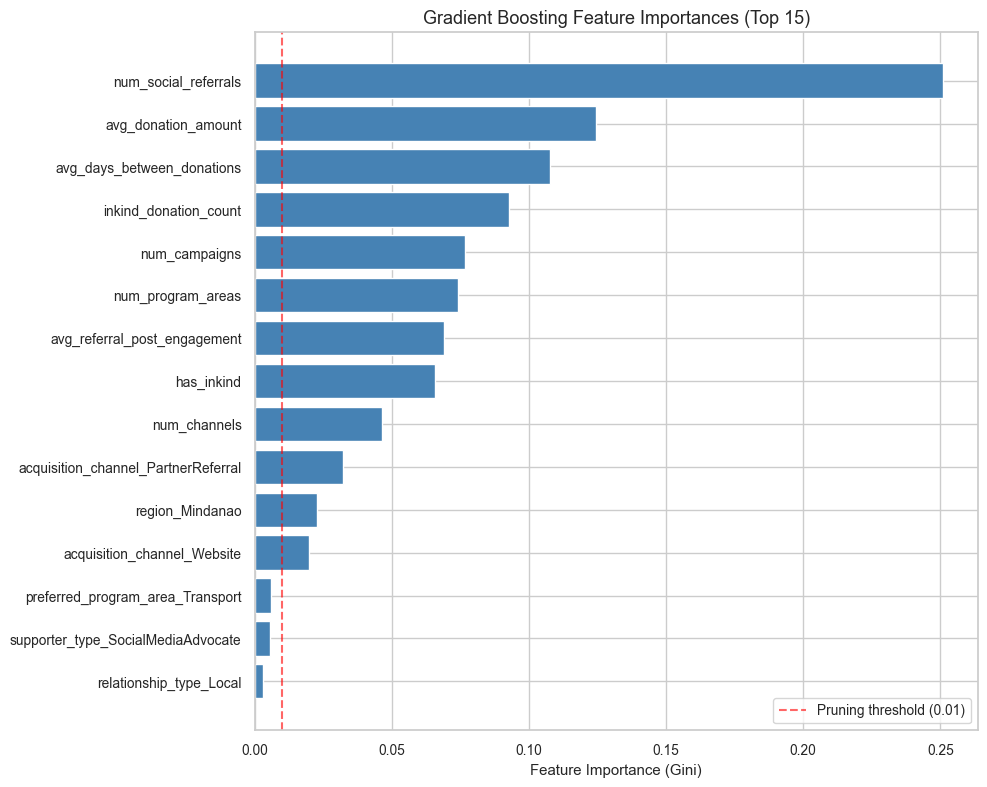

Features below 0.01 importance threshold:
  Total: 21 of 33
  Numeric features to prune: ['ever_recurring']
  (Categorical dummy variables with low importance are not pruned individually —
   removing one level of a one-hot encoded variable would distort the encoding.)


In [26]:
# -- 6a. Extract feature importances from best predictive model -------------

# Get the best GB model from Track B (already fitted in Step 4)
best_gb = models['Gradient Boosting'].best_estimator_

# Extract encoded feature names
cat_encoded_names = list(
    best_gb.named_steps['prep']
    .named_transformers_['cat']
    .get_feature_names_out(cat_features)
)
all_feature_names = vif_pruned_numeric + cat_encoded_names

# Tree-based feature importances (Gini importance)
gb_importances = best_gb.named_steps['clf'].feature_importances_

fi_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': gb_importances,
}).sort_values('importance', ascending=False)

# Visualize
fig, ax = plt.subplots(figsize=(10, 8))
fi_plot = fi_df.head(15)  # top 15 for readability
ax.barh(fi_plot['feature'][::-1], fi_plot['importance'][::-1], color='steelblue', edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Gradient Boosting Feature Importances (Top 15)', fontsize=13)
ax.axvline(0.01, color='red', linestyle='--', alpha=0.6, label='Pruning threshold (0.01)')
ax.legend()
plt.tight_layout()
plt.show()

# Identify low-importance features
IMPORTANCE_THRESHOLD = 0.01
low_imp = fi_df[fi_df['importance'] < IMPORTANCE_THRESHOLD]
low_imp_numeric = [f for f in low_imp['feature'] if f in vif_pruned_numeric]

print(f'Features below {IMPORTANCE_THRESHOLD} importance threshold:')
print(f'  Total: {len(low_imp)} of {len(fi_df)}')
print(f'  Numeric features to prune: {low_imp_numeric}')
print(f'  (Categorical dummy variables with low importance are not pruned individually \u2014')
print(f'   removing one level of a one-hot encoded variable would distort the encoding.)')

In [27]:
# -- 6b. Retrain without low-importance features and compare ------------

# Build pruned feature set
final_numeric = [f for f in vif_pruned_numeric if f not in low_imp_numeric]

print(f'Pruned numeric features ({len(final_numeric)}): {final_numeric}')
print(f'Dropped: {low_imp_numeric}')

# Rebuild preprocessor with pruned features
pruned_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), final_numeric),
    ('cat', OneHotEncoder(drop='first', sparse_output=False,
                          handle_unknown='infrequent_if_exist'), cat_features),
], remainder='drop')

# Retrain GB with same hyperparameter search
gb_pruned_grid = GridSearchCV(
    Pipeline([('prep', pruned_preprocessor), ('clf', GradientBoostingClassifier(random_state=42))]),
    param_grid={
        'clf__n_estimators': [50, 100],
        'clf__max_depth': [2, 3],
        'clf__learning_rate': [0.05, 0.1],
    },
    cv=cv, scoring='roc_auc', refit=True,
)
gb_pruned_grid.fit(X_train, y_train)

full_auc = models['Gradient Boosting'].best_score_
pruned_auc = gb_pruned_grid.best_score_

print(f'\nCross-validated AUC-ROC comparison:')
print(f'  Full model ({len(vif_pruned_numeric)} numeric features):    {full_auc:.3f}')
print(f'  Pruned model ({len(final_numeric)} numeric features):   {pruned_auc:.3f}')
print(f'  Difference:                            {pruned_auc - full_auc:+.3f}')

if pruned_auc >= full_auc - 0.01:
    print('\n\u2713 Pruned model performs equivalently \u2014 adopting the leaner model.')
else:
    print('\n\u2717 Pruning degraded performance \u2014 keeping full model.')

Pruned numeric features (9): ['avg_days_between_donations', 'avg_donation_amount', 'num_campaigns', 'num_channels', 'num_program_areas', 'inkind_donation_count', 'has_inkind', 'num_social_referrals', 'avg_referral_post_engagement']
Dropped: ['ever_recurring']

Cross-validated AUC-ROC comparison:
  Full model (10 numeric features):    0.850
  Pruned model (9 numeric features):   0.875
  Difference:                            +0.025

✓ Pruned model performs equivalently — adopting the leaner model.


In [28]:
# -- 7a. Serialize the final model for deployment -------------------------
import joblib
from pathlib import Path

MODEL_DIR = Path('models')
MODEL_DIR.mkdir(exist_ok=True)

# Save the pruned model (includes preprocessor + classifier)
model_path = MODEL_DIR / 'donor_churn_model.joblib'
joblib.dump(gb_pruned_grid.best_estimator_, model_path)

# Save the feature configuration for the API to reference
feature_config = {
    'numeric_features': final_numeric,
    'categorical_features': cat_features,
    'risk_thresholds': {'High': 0.6, 'Medium': 0.3, 'Low': 0.0},
    'churn_threshold_days': 180,
}
joblib.dump(feature_config, MODEL_DIR / 'feature_config.joblib')

print(f'Model saved to: {model_path}')
print(f'Model size: {model_path.stat().st_size / 1024:.1f} KB')
print(f'Feature config saved to: {MODEL_DIR / "feature_config.joblib"}')

# Verify it loads correctly
loaded_model = joblib.load(model_path)
test_pred = loaded_model.predict_proba(X_test)[:, 1]
print(f'\nVerification: loaded model produces {len(test_pred)} predictions on test set.')
print(f'Sample risk scores: {test_pred[:5].round(3)}')

Model saved to: models\donor_churn_model.joblib
Model size: 71.9 KB
Feature config saved to: models\feature_config.joblib

Verification: loaded model produces 11 predictions on test set.
Sample risk scores: [0.376 0.521 0.185 0.094 0.129]
